# 04 · Attention: BiLSTM vs BiLSTM + Attention

**DeepCodeGuard** · Week 4

Last week the BiLSTM squeezed a whole function (up to 512 tokens) into **one final hidden vector**, and it lost to TF-IDF. **Attention** removes that bottleneck. The model keeps the hidden state of *every* token, gives each one a learned weight, and takes a weighted average:

$$e_t = v^\top \tanh(W h_t + b) \qquad \alpha_t = \frac{\exp(e_t)}{\sum_k \exp(e_k)} \qquad c = \sum_t \alpha_t h_t$$

The weights $\alpha_t$ sum to 1, and the context vector $c$ goes to the classifier.

**Ablation design.** We compare three ways to turn the BiLSTM's hidden states into one vector. Everything else is identical:

| Variant | Pooling | Question it answers |
|---|---|---|
| **BiLSTM (last)** | final forward + backward state | Week 3 model, re-run as the reference |
| **BiLSTM + Max-pool** | element-wise max over all positions | Does simply *using all positions* help? |
| **BiLSTM + Attention** | learned weighted average | Does *learning which tokens matter* help beyond that? |

The max-pool row is a **control**. Without it, we couldn't tell whether a gain comes from attention itself or just from looking at every position.

> ⚙️ Runtime → Change runtime type → **T4 GPU**. 3 variants × 3 seeds ≈ 15–25 minutes. Wait for section 9 before saving to GitHub.

## 0 · Setup

In [1]:
!git clone -q https://github.com/reenupalle/deepcodeguard.git 2>/dev/null || (cd deepcodeguard && git pull -q)
%cd /content/deepcodeguard
!pip install -q datasets
!python src/deepcodeguard/data/download.py

/content/deepcodeguard
README.md: 100% 5.60k/5.60k [00:00<00:00, 14.5MB/s]

data/train-00000-of-00001.parquet: downloading bytes:  94% 16.8M/17.8M [00:01<00:00, 24.7MB/s,  533kB/s  ]
data/train-00000-of-00001.parquet: downloading bytes: 100% 17.7M/17.7M [00:01<00:00, 17.0MB/s, 1.71MB/s  ]
data/train-00000-of-00001.parquet: reconstructing file: 100% 17.8M/17.8M [00:01<00:00, 17.1MB/s, 1.74MB/s  ]

data/validation-00000-of-00001.parquet: downloading bytes:   8% 172k/2.21M [00:00<00:07, 278kB/s]
data/validation-00000-of-00001.parquet: downloading bytes: 100% 2.20M/2.20M [00:00<00:00, 3.12MB/s,  216kB/s  ]
data/validation-00000-of-00001.parquet: reconstructing file: 100% 2.21M/2.21M [00:00<00:00, 3.14MB/s,  218kB/s  ]

data/test-00000-of-00001.parquet: downloading bytes:  38% 858k/2.23M [00:00<00:00, 1.66MB/s]
data/test-00000-of-00001.parquet: downloading bytes: 100% 2.21M/2.21M [00:00<00:00, 3.87MB/s,  218kB/s  ]
data/test-00000-of-00001.parquet: reconstructing file: 100% 2.23M/2.23M [00:

## 1 · Configuration
Same hyperparameters as notebook 03, so the comparison is fair.

In [2]:
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "src")
from deepcodeguard.evaluation.metrics import val_then_test

CONFIG = {
    "max_len": 512, "min_freq": 3, "max_vocab": 30_000,
    "embedding_dim": 128, "hidden_dim": 128, "dropout": 0.3,
    "attention_dim": 128,
    "batch_size": 64, "lr": 1e-3, "max_epochs": 10, "patience": 2, "grad_clip": 1.0,
}
SEEDS = [42, 43, 44]
VARIANTS = {"BiLSTM (last)": "last", "BiLSTM + Max-pool": "max", "BiLSTM + Attention": "attention"}
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 2 · Data and vocabulary (identical to notebook 03)

In [3]:
data = {s: pd.read_json(f"data/raw/{s}.jsonl", lines=True) for s in ["train", "validation", "test"]}
y = {s: d["target"].astype(int).values for s, d in data.items()}

TOKEN_RE = re.compile(r"[A-Za-z_]\w*|\d+|\S")
PAD, UNK = 0, 1
tokens = {s: [TOKEN_RE.findall(code) for code in d["func"]] for s, d in data.items()}
counts = Counter(t for toks in tokens["train"] for t in toks)
vocab = ["<pad>", "<unk>"] + [t for t, c in counts.most_common(CONFIG["max_vocab"]) if c >= CONFIG["min_freq"]]
stoi = {t: i for i, t in enumerate(vocab)}


def encode(toks):
    ids = [stoi.get(t, UNK) for t in toks[:CONFIG["max_len"]]]
    return ids + [PAD] * (CONFIG["max_len"] - len(ids)), max(len(ids), 1)


def make_dataset(split):
    ids, lengths = zip(*(encode(t) for t in tokens[split]))
    return TensorDataset(torch.tensor(ids), torch.tensor(lengths), torch.tensor(y[split], dtype=torch.float32))


datasets = {s: make_dataset(s) for s in data}
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 30,002


## 3 · The attention layer
For every position, a small network scores how important that hidden state is. **Padding positions are masked out** (score = −∞) so they get zero weight. Softmax turns the scores into weights that sum to 1.

In [4]:
class AdditiveAttention(nn.Module):
    """Bahdanau-style attention pooling: one learned weight per token."""

    def __init__(self, input_dim, attention_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, attention_dim)
        self.score = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, states, mask):
        # states: (batch, time, features); mask: (batch, time), True for real tokens
        scores = self.score(torch.tanh(self.proj(states))).squeeze(-1)
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), states).squeeze(1)
        return context, weights

## 4 · The model with three pooling options

In [5]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, pooling="last", embedding_dim=128, hidden_dim=128,
                 attention_dim=128, dropout=0.3, **_):
        super().__init__()
        self.pooling = pooling
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        if pooling == "attention":
            self.attention = AdditiveAttention(2 * hidden_dim, attention_dim)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(2 * hidden_dim, 1)

    def forward(self, ids, lengths, return_attention=False):
        packed = pack_padded_sequence(self.embedding(ids), lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, (hidden, _) = self.rnn(packed)
        weights = None
        if self.pooling == "last":
            pooled = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            states, _ = pad_packed_sequence(outputs, batch_first=True, total_length=ids.size(1))
            mask = ids != PAD
            if self.pooling == "max":
                pooled = states.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
            else:
                pooled, weights = self.attention(states, mask)
        logits = self.head(self.dropout(pooled)).squeeze(-1)
        return (logits, weights) if return_attention else logits


for name, pooling in VARIANTS.items():
    m = BiLSTMClassifier(len(vocab), pooling, **CONFIG)
    print(f"{name:<20} parameters: {sum(p.numel() for p in m.parameters()):,}")

BiLSTM (last)        parameters: 4,104,705
BiLSTM + Max-pool    parameters: 4,104,705
BiLSTM + Attention   parameters: 4,137,729


## 5 · Training loop (same as notebook 03)

In [6]:
from sklearn.metrics import roc_auc_score


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def predict(model, split):
    model.eval()
    out = []
    with torch.no_grad():
        for ids, lengths, _ in DataLoader(datasets[split], batch_size=256):
            out.append(torch.sigmoid(model(ids.to(device), lengths)).cpu().numpy())
    return np.concatenate(out)


def train_one(name, seed):
    set_seed(seed)
    model = BiLSTMClassifier(len(vocab), VARIANTS[name], **CONFIG).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(datasets["train"], batch_size=CONFIG["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    best_auc, best_state, bad, history = 0.0, None, 0, []
    start = time.time()
    for epoch in range(1, CONFIG["max_epochs"] + 1):
        model.train()
        total = 0.0
        for ids, lengths, target in loader:
            opt.zero_grad()
            loss = loss_fn(model(ids.to(device), lengths), target.to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            opt.step()
            total += loss.item() * len(target)
        val_auc = roc_auc_score(y["validation"], predict(model, "validation"))
        history.append({"model": name, "seed": seed, "epoch": epoch,
                        "train_loss": total / len(datasets["train"]), "val_roc_auc": val_auc})
        print(f"  epoch {epoch:>2}  loss {history[-1]['train_loss']:.4f}  val ROC-AUC {val_auc:.4f}")
        if val_auc > best_auc:
            best_auc, bad = val_auc, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CONFIG["patience"]:
                break
    model.load_state_dict(best_state)
    t, val, test = val_then_test(y["validation"], predict(model, "validation"),
                                 y["test"], predict(model, "test"))
    row = {"model": name, "seed": seed, "threshold": round(t, 2),
           "best_epoch": int(np.argmax([h["val_roc_auc"] for h in history]) + 1),
           "train_minutes": round((time.time() - start) / 60, 1), "val_f1": val["f1"],
           **{f"test_{k}": v for k, v in test.items()}}
    print(f"  → test F1 {test['f1']:.3f}  ROC-AUC {test['roc_auc']:.3f}  (threshold {t:.2f})")
    return row, history, model

## 6 · Run the ablation
We keep the attention model from the first seed for visualisation in section 8.

In [7]:
RUNS, HISTORY = [], []
attention_model = None
for name in VARIANTS:
    for seed in SEEDS:
        print(f"\n=== {name}  seed {seed} ===")
        row, hist, model = train_one(name, seed)
        RUNS.append(row)
        HISTORY.extend(hist)
        if VARIANTS[name] == "attention" and attention_model is None:
            attention_model = model

runs = pd.DataFrame(RUNS)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
runs.to_csv("reports/tables/attention_runs.csv", index=False)
runs.round(3)


=== BiLSTM (last)  seed 42 ===
  epoch  1  loss 0.6785  val ROC-AUC 0.6185
  epoch  2  loss 0.6527  val ROC-AUC 0.6504
  epoch  3  loss 0.6144  val ROC-AUC 0.6516
  epoch  4  loss 0.5591  val ROC-AUC 0.6687
  epoch  5  loss 0.4971  val ROC-AUC 0.6664
  epoch  6  loss 0.4296  val ROC-AUC 0.6607
  → test F1 0.653  ROC-AUC 0.644  (threshold 0.23)

=== BiLSTM (last)  seed 43 ===
  epoch  1  loss 0.6783  val ROC-AUC 0.6264
  epoch  2  loss 0.6510  val ROC-AUC 0.6561
  epoch  3  loss 0.6127  val ROC-AUC 0.6752
  epoch  4  loss 0.5610  val ROC-AUC 0.6761
  epoch  5  loss 0.5010  val ROC-AUC 0.6723
  epoch  6  loss 0.4329  val ROC-AUC 0.6541
  → test F1 0.652  ROC-AUC 0.649  (threshold 0.15)

=== BiLSTM (last)  seed 44 ===
  epoch  1  loss 0.6792  val ROC-AUC 0.6171
  epoch  2  loss 0.6540  val ROC-AUC 0.6439
  epoch  3  loss 0.6133  val ROC-AUC 0.6569
  epoch  4  loss 0.5626  val ROC-AUC 0.6690
  epoch  5  loss 0.4942  val ROC-AUC 0.6710
  epoch  6  loss 0.4270  val ROC-AUC 0.6692
  epoch  7

,model,seed,threshold,best_epoch,train_minutes,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,BiLSTM (last),42,0.23,4,1.6,0.640,0.552,0.507,0.918,0.653,0.644,0.601
1,BiLSTM (last),43,0.15,4,1.5,0.641,0.531,0.495,0.955,0.652,0.649,0.602
2,BiLSTM (last),44,0.20,5,1.7,0.640,0.557,0.510,0.876,0.645,0.653,0.617
3,BiLSTM + Max-pool,42,0.24,5,2.6,0.655,0.582,0.527,0.876,0.658,0.680,0.639
4,BiLSTM + Max-pool,43,0.20,5,2.6,0.644,0.552,0.507,0.934,0.657,0.672,0.635
5,BiLSTM + Max-pool,44,0.23,5,2.7,0.649,0.570,0.518,0.934,0.666,0.680,0.639
6,BiLSTM + Attention,42,0.20,3,1.9,0.647,0.546,0.503,0.939,0.655,0.672,0.633
7,BiLSTM + Attention,43,0.26,3,1.9,0.646,0.567,0.516,0.942,0.667,0.683,0.638
8,BiLSTM + Attention,44,0.14,5,2.7,0.646,0.575,0.521,0.907,0.662,0.676,0.630


## 7 · Results: mean ± std over seeds
The TF-IDF and GRU/LSTM rows are copied from notebooks 02 and 03 for context.

In [8]:
metrics = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc"]
summary = runs.groupby("model", sort=False)[metrics].agg(["mean", "std"])
table = pd.DataFrame({m.replace("test_", ""): summary[(m, "mean")].map("{:.3f}".format) + " ± "
                      + summary[(m, "std")].map("{:.3f}".format) for m in metrics})
previous = pd.DataFrame({
    "f1": ["0.662", "0.639 ± 0.011", "0.636 ± 0.008"],
    "roc_auc": ["0.684", "0.629 ± 0.007", "0.621 ± 0.008"],
    "pr_auc": ["0.639", "0.588 ± 0.008", "0.569 ± 0.011"],
}, index=["TF-IDF + LogReg (nb 02)", "GRU (nb 03)", "LSTM (nb 03)"])
comparison = pd.concat([previous, table])[table.columns].fillna("")
comparison.to_csv("reports/tables/attention_vs_previous.csv")
comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
TF-IDF + LogReg (nb 02),,,,0.662,0.684,0.639
GRU (nb 03),,,,0.639 ± 0.011,0.629 ± 0.007,0.588 ± 0.008
LSTM (nb 03),,,,0.636 ± 0.008,0.621 ± 0.008,0.569 ± 0.011
BiLSTM (last),0.547 ± 0.013,0.504 ± 0.008,0.916 ± 0.039,0.650 ± 0.004,0.649 ± 0.004,0.607 ± 0.009
BiLSTM + Max-pool,0.568 ± 0.015,0.517 ± 0.010,0.914 ± 0.034,0.661 ± 0.005,0.677 ± 0.005,0.638 ± 0.002
BiLSTM + Attention,0.563 ± 0.015,0.513 ± 0.009,0.929 ± 0.020,0.661 ± 0.006,0.677 ± 0.005,0.634 ± 0.004


## 8 · What does attention look at?
Below are a few **test functions the model flags as vulnerable**, with each token shaded by its attention weight (darker = more weight). The top-weighted tokens are listed underneath.

⚠️ **Important caveat (from the spec):** attention weights are **not a faithful explanation** of *why* the model decided. They show where the pooling layer put weight, which is a hint, not a proof. Proper attribution methods (Integrated Gradients) come in Week 7.

In [9]:
from html import escape

from IPython.display import HTML, display


def show_attention(index, max_tokens=150):
    ids, length, label = datasets["test"][index]
    attention_model.eval()
    with torch.no_grad():
        logit, weights = attention_model(ids.unsqueeze(0).to(device), length.unsqueeze(0), return_attention=True)
    prob = torch.sigmoid(logit).item()
    w = weights[0, :length].cpu().numpy()
    toks = tokens["test"][index][:length]
    scale = w.max()
    spans = "".join(
        f'<span style="background: rgba(235,104,52,{0.85 * wt / scale:.2f}); padding:1px 2px; border-radius:3px">{escape(tok)}</span> '
        for tok, wt in zip(toks[:max_tokens], w[:max_tokens]))
    top = sorted(zip(w, toks), reverse=True)[:8]
    display(HTML(
        f"<p><b>Test #{index}</b> · true label: <b>{'vulnerable' if label == 1 else 'secure'}</b> · "
        f"P(vulnerable) = <b>{prob:.2f}</b></p>"
        f'<div style="font-family:monospace; font-size:12px; line-height:1.9">{spans}{" …" if length > max_tokens else ""}</div>'
        f"<p>Top tokens: {', '.join(f'<code>{escape(t)}</code> ({wt:.3f})' for wt, t in top)}</p><hr>"))


test_probs = predict(attention_model, "test")
confident_hits = [i for i in np.argsort(-test_probs) if y["test"][i] == 1 and len(tokens["test"][i]) < 150][:3]
for i in confident_hits:
    show_attention(int(i))

**Which tokens get the most attention overall?** We average each token's weight across all test functions it appears in (tokens seen at least 30 times).

In [10]:
token_weights = {}
attention_model.eval()
with torch.no_grad():
    for start in range(0, len(datasets["test"]), 256):
        ids, lengths, _ = datasets["test"][start:start + 256]
        _, weights = attention_model(ids.to(device), lengths, return_attention=True)
        for row_ids, row_w, n in zip(ids, weights.cpu().numpy(), lengths):
            n = int(n)
            for tok_id, wt in zip(row_ids[:n].tolist(), row_w[:n] * n):   # × length: 1.0 = average weight
                token_weights.setdefault(vocab[tok_id], []).append(wt)

top_tokens = (pd.Series({t: np.mean(w) for t, w in token_weights.items() if len(w) >= 30})
              .sort_values(ascending=False).head(20).round(2))
print("Relative attention (1.0 = average token):")
top_tokens

Relative attention (1.0 = average token):


,0
MpegEncContext,24.549999
volatile,21.730000
init_vlc,21.379999
avio_read,21.150000
CPUState,19.139999
coded_frame,16.540001
ERROR,14.550000
AV_RL32,14.120000
avio_tell,13.780000
offsetof,13.630000


## 9 · Learning curves

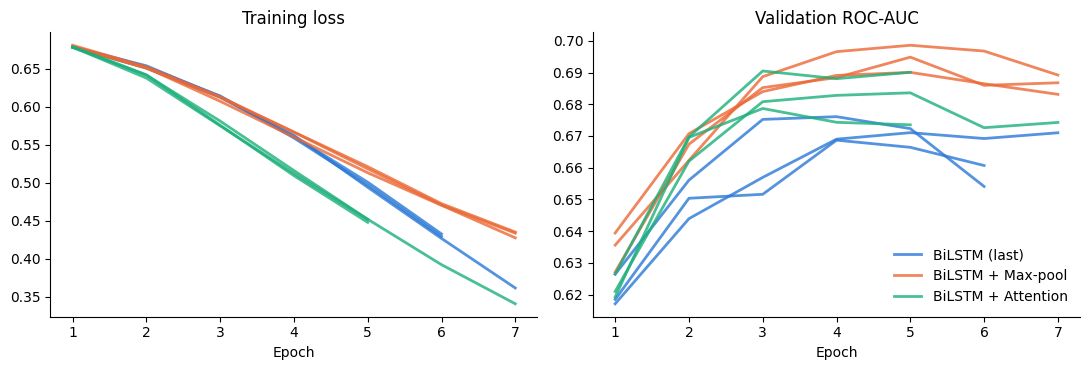

In [11]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(HISTORY)
colors = {"BiLSTM (last)": "#2a78d6", "BiLSTM + Max-pool": "#eb6834", "BiLSTM + Attention": "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, seed), h in hist.groupby(["model", "seed"], sort=False):
    label = name if seed == SEEDS[0] else None
    axes[0].plot(h["epoch"], h["train_loss"], color=colors[name], linewidth=2, alpha=0.8, label=label)
    axes[1].plot(h["epoch"], h["val_roc_auc"], color=colors[name], linewidth=2, alpha=0.8, label=label)
axes[0].set_title("Training loss")
axes[1].set_title("Validation ROC-AUC")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/attention_learning_curves.png", dpi=150)
plt.show()

## Findings
_Fill in after running:_
- _Experiment 3: does attention beat the plain BiLSTM, beyond the std?_
- _Does it also beat max-pooling (the control)? If not, the gain comes from using all positions, not from attention itself._
- _How does the best model now compare with TF-IDF?_
- _What do the highlighted tokens look like: security-relevant APIs (`memcpy`, `free`, bounds checks) or project-specific names?_